### Import Required Libraries.

In [67]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

from sklearn.metrics import accuracy_score, classification_report

In [28]:
# import the dataset.
data = load_iris()

In [29]:
# load the dataset. 
X = data.data[ : , 0:2]
y = data.target

In [31]:
# train-test-split. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [33]:
# shape of all division data.
print(X_train.shape)
print(X_test.shape) 
print(y_train.shape)
print(y_test.shape)

(120, 2)
(30, 2)
(120,)
(30,)


In [55]:
# apply the model. 
clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [56]:
y_pred = clf.predict(X_test)

In [57]:
# accuracy score. 
print('Accuarcy : ', accuracy_score(y_test, y_pred))

Accuarcy :  0.7666666666666667


In [58]:
# classification_report. 
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.57      0.50      0.53         8
           2       0.60      0.75      0.67         8

    accuracy                           0.77        30
   macro avg       0.72      0.73      0.72        30
weighted avg       0.78      0.77      0.77        30



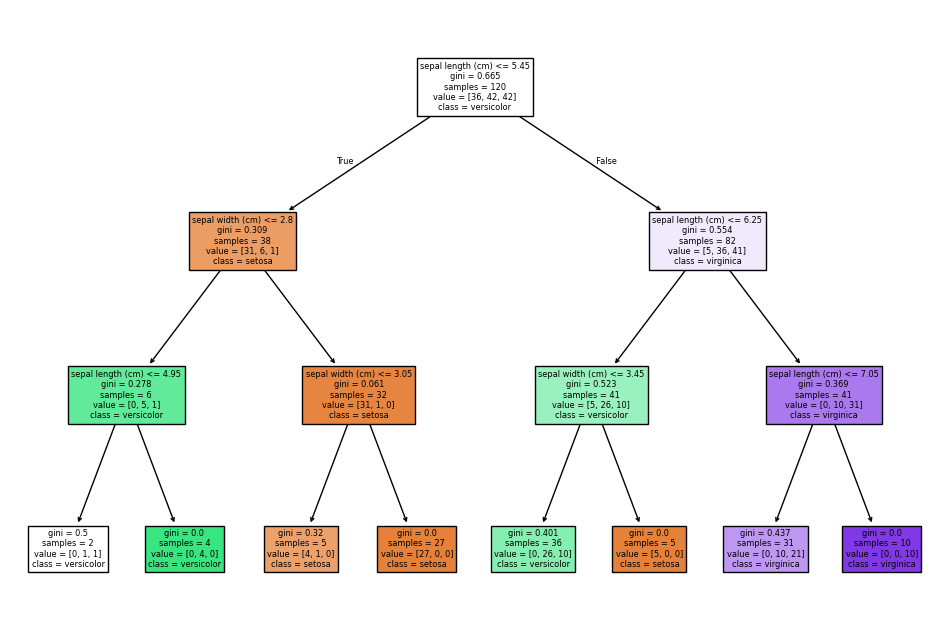

In [59]:
# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=data.feature_names[:2], class_names=data.target_names)
plt.show()

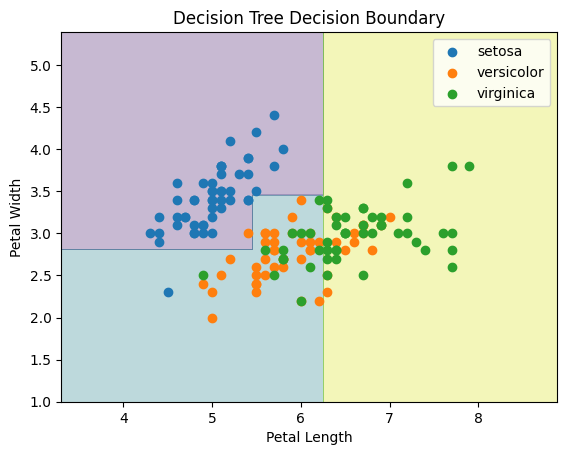

In [65]:
# Define grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

# predict for every Grid point. 
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.figure()

# Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot actual data points
for i in range(3):
    plt.scatter(X[y == i, 0], X[y == i, 1], label=data.target_names[i])

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Decision Tree Decision Boundary")
plt.legend()
plt.show()

In [68]:
## We can visualize the Decision tree as if-else statement. 
r = export_text(clf, feature_names=['sepal_length','sepal_width'])
print(r)

|--- sepal_length <= 5.45
|   |--- sepal_width <= 2.80
|   |   |--- sepal_length <= 4.95
|   |   |   |--- class: 1
|   |   |--- sepal_length >  4.95
|   |   |   |--- class: 1
|   |--- sepal_width >  2.80
|   |   |--- sepal_width <= 3.05
|   |   |   |--- class: 0
|   |   |--- sepal_width >  3.05
|   |   |   |--- class: 0
|--- sepal_length >  5.45
|   |--- sepal_length <= 6.25
|   |   |--- sepal_width <= 3.45
|   |   |   |--- class: 1
|   |   |--- sepal_width >  3.45
|   |   |   |--- class: 0
|   |--- sepal_length >  6.25
|   |   |--- sepal_length <= 7.05
|   |   |   |--- class: 2
|   |   |--- sepal_length >  7.05
|   |   |   |--- class: 2



### Regression using DT.

C:\Users\Mohd Uzaif\AppData\Local\Temp\ipykernel_6500\2501677197.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01)[:, np.newaxis]


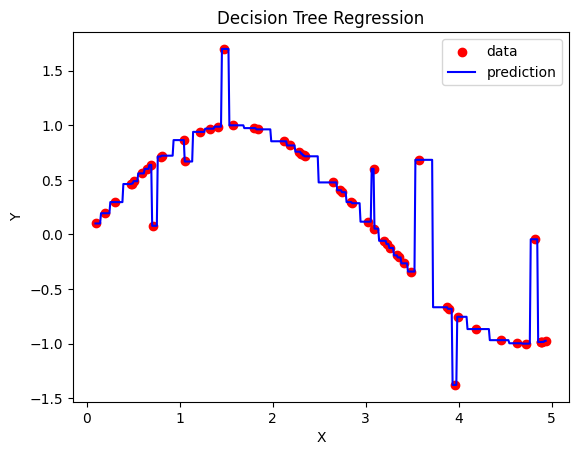

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import numpy as np

# Generate a non-linear dataset based on the sine function
np.random.seed(0)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - np.random.rand(16))  # add some noise to the data

# Split into training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit a Decision Tree regressor
regressor = DecisionTreeRegressor()
regressor.fit(X_train, y_train)

# To plot the regression curve, we'll sort the X values and predict Y values for the sorted X
X_grid = np.arange(min(X), max(X), 0.01)[:, np.newaxis]
y_grid = regressor.predict(X_grid)

# Plot the training data and the regression curve
plt.scatter(X_train, y_train, color='red', label='data')
plt.plot(X_grid, y_grid, color='blue', label='prediction')
plt.title('Decision Tree Regression')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()


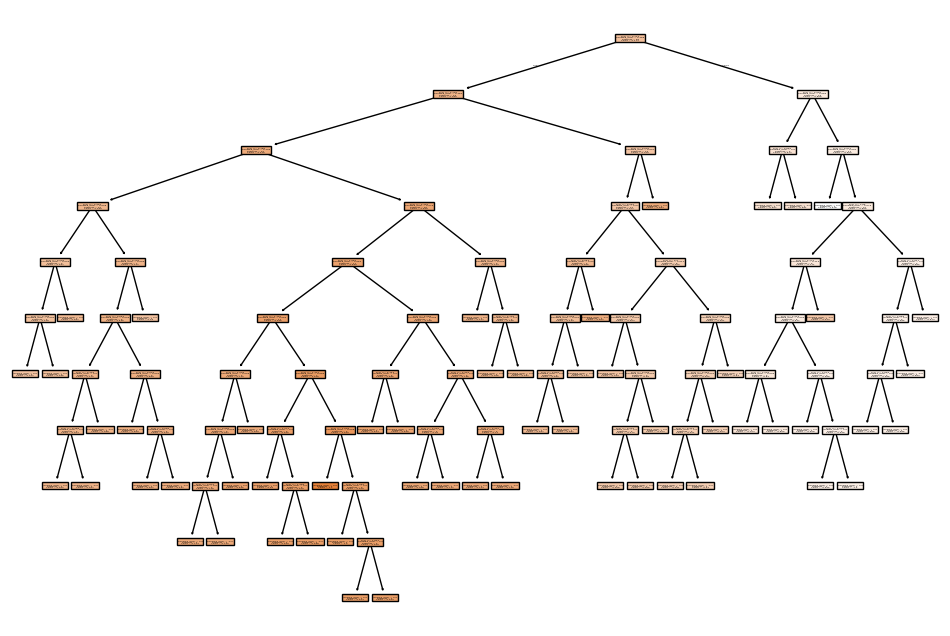

In [70]:
from sklearn.tree import plot_tree
# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(regressor, filled=True)
plt.show()